  BREAST CANCER — BINARY LOGISTIC REGRESSION
Shape: (569, 30) | Classes: ['malignant' 'benign']
Malignant: 212 | Benign: 357

✅ Manual Accuracy  : 0.9825
✅ sklearn Accuracy : 0.9737

Feature                            Manual W    sklearn W     |Diff|
------------------------------------------------------------------
mean radius                         -0.5464      -0.4346     0.1117
mean texture                        -0.6578      -0.3972     0.2606
mean perimeter                      -0.5241      -0.3961     0.1281
mean area                           -0.5780      -0.4700     0.1080
mean smoothness                     -0.2023      -0.0674     0.1349
mean compactness                     0.1614       0.5267     0.3654
mean concavity                      -0.6330      -0.8077     0.1747
mean concave points                 -0.7688      -1.1077     0.3390
mean symmetry                        0.0417       0.2415     0.1998
mean fractal dimension               0.3072       0.0784     0.2288


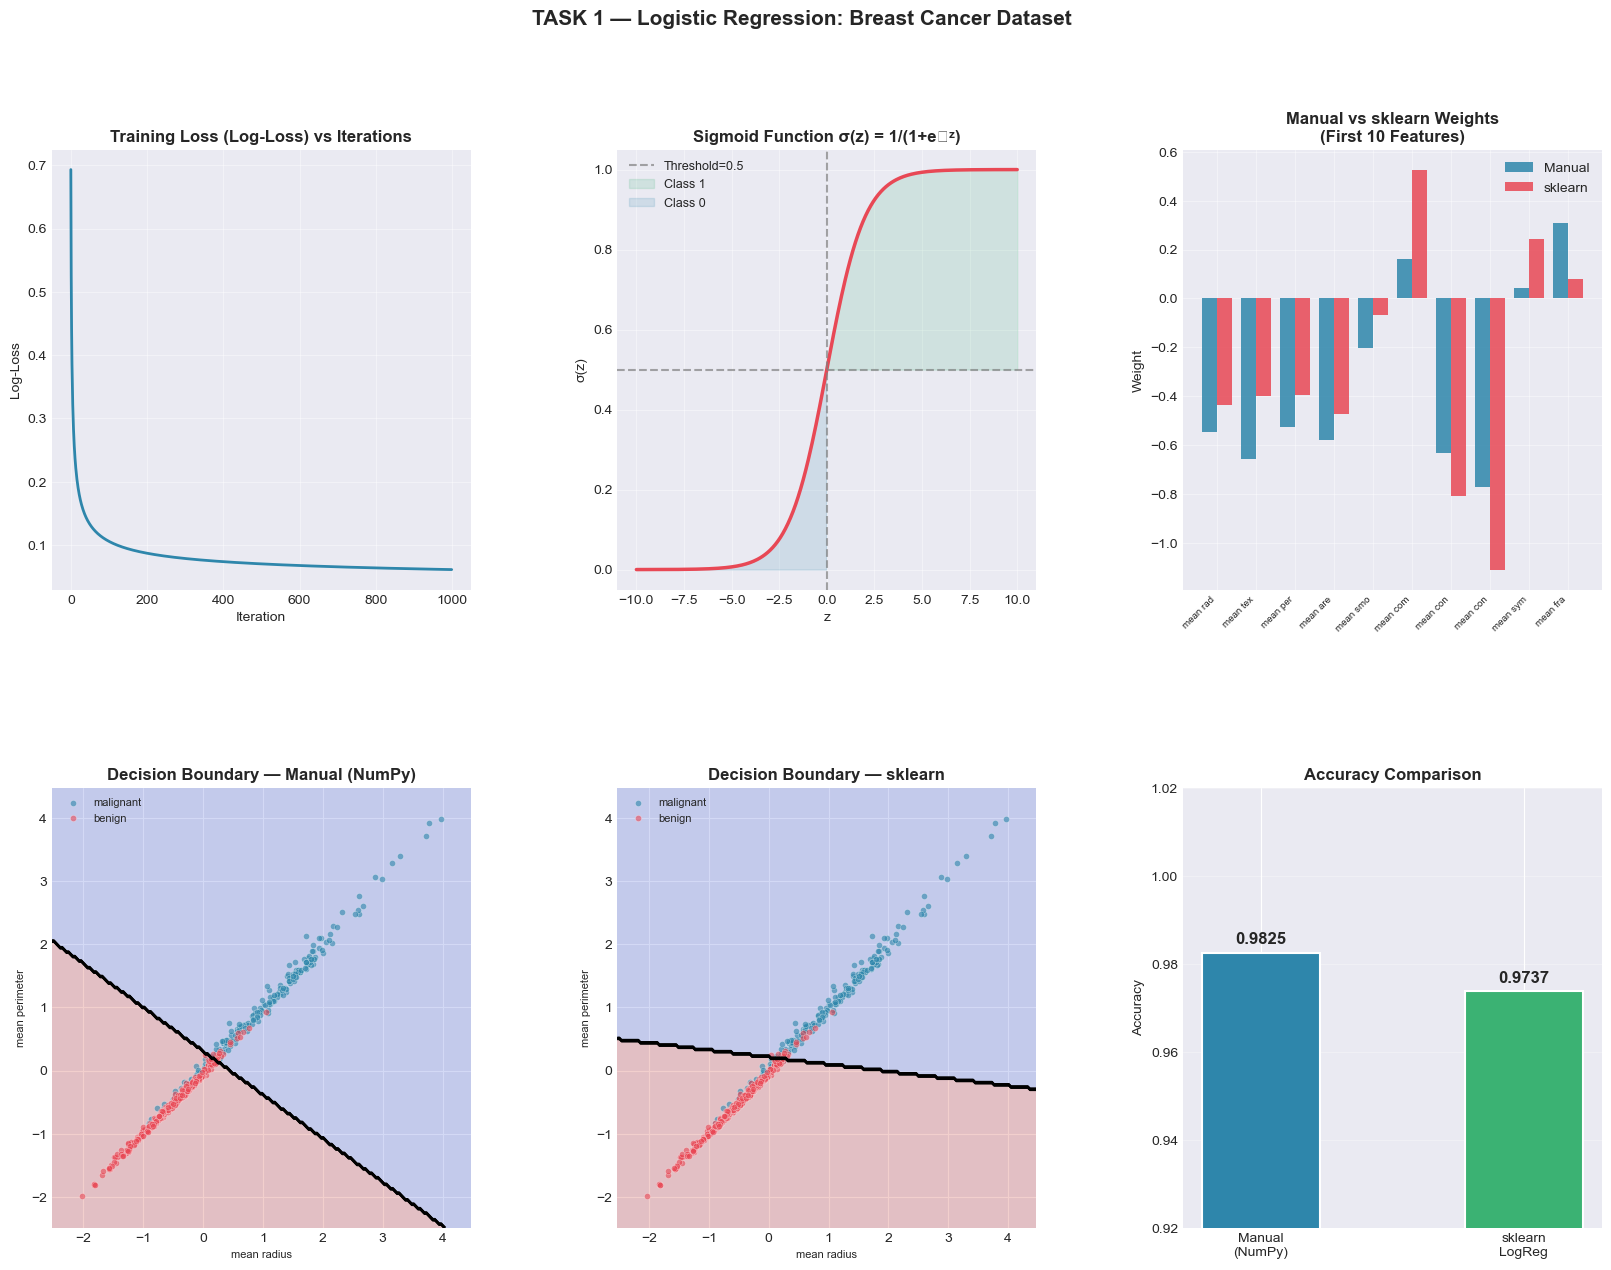


  IRIS DATASET — MULTICLASS LOGISTIC REGRESSION (OvR)

✅ OvR Accuracy: 1.0000

#        Setosa   Versiclr  Virginica    Predicted       Actual
------------------------------------------------------------
1        0.0115     0.8744     0.1141   versicolor   versicolor
2        0.9652     0.0348     0.0000       setosa       setosa
3        0.0000     0.0030     0.9970    virginica    virginica
4        0.0135     0.7583     0.2282   versicolor   versicolor
5        0.0019     0.7499     0.2482   versicolor   versicolor
6        0.9325     0.0675     0.0000       setosa       setosa
7        0.0906     0.8766     0.0328   versicolor   versicolor
8        0.0001     0.0656     0.9343    virginica    virginica


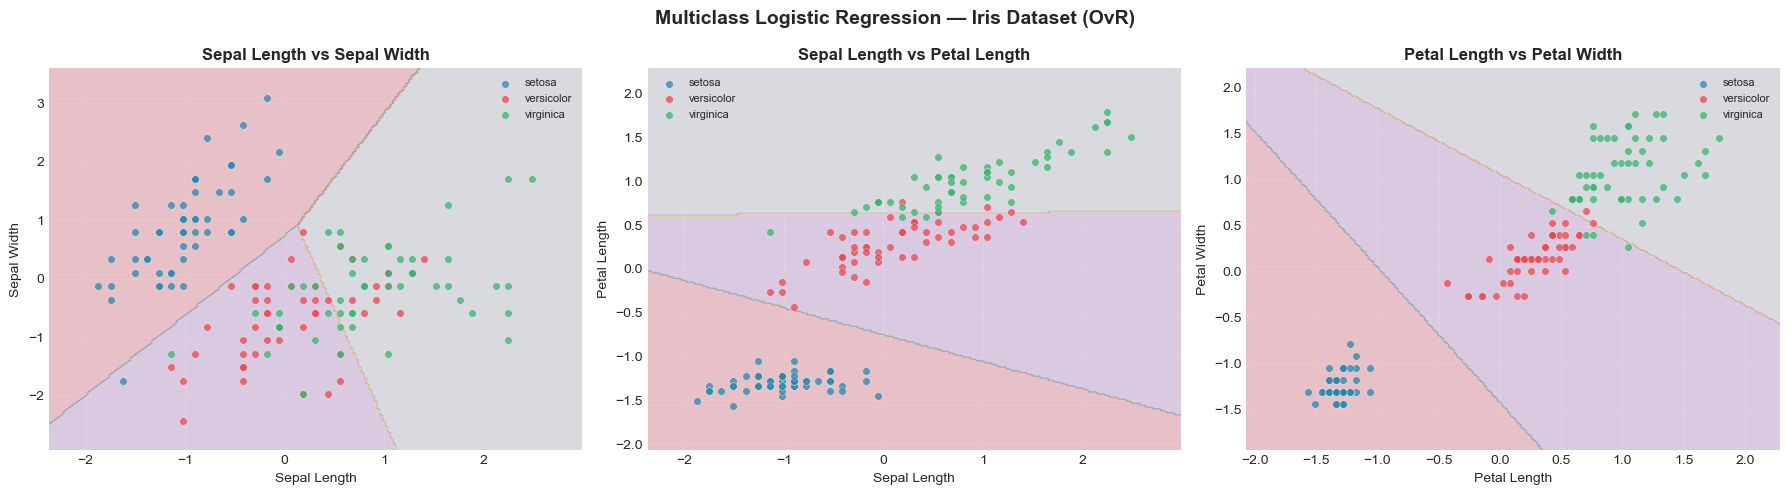


✅ TASK 1 COMPLETE!


In [1]:
# ============================================================
# TASK 1: LOGISTIC REGRESSION FROM SCRATCH + SKLEARN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
COLORS = ['#2E86AB', '#E84855', '#3BB273', '#F4A261', '#8338EC']

# ============================================================
# MANUAL LOGISTIC REGRESSION CLASS (NumPy from Scratch)
# ============================================================

class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr           = learning_rate
        self.n_iterations = n_iterations
        self.weights      = None
        self.bias         = None
        self.loss_history = []

    def sigmoid(self, z):
        # Clip to avoid overflow in exp
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def compute_loss(self, y, y_pred):
        eps = 1e-9
        return -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias    = 0

        for _ in range(self.n_iterations):
            z      = X @ self.weights + self.bias
            y_pred = self.sigmoid(z)

            dw = (1 / n_samples) * X.T @ (y_pred - y)
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            self.loss_history.append(self.compute_loss(y, y_pred))

    def predict_proba(self, X):
        return self.sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# ============================================================
# BREAST CANCER DATASET — BINARY CLASSIFICATION
# ============================================================

print("=" * 62)
print("  BREAST CANCER — BINARY LOGISTIC REGRESSION")
print("=" * 62)

data = load_breast_cancer()
X, y = data.data, data.target
print(f"Shape: {X.shape} | Classes: {data.target_names}")
print(f"Malignant: {np.sum(y==0)} | Benign: {np.sum(y==1)}")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train manual model
manual_model = LogisticRegressionScratch(learning_rate=0.1, n_iterations=1000)
manual_model.fit(X_train, y_train)
manual_acc = accuracy_score(y_test, manual_model.predict(X_test))

# Train sklearn model
sklearn_model = LogisticRegression(max_iter=1000, random_state=42)
sklearn_model.fit(X_train, y_train)
sklearn_acc = accuracy_score(y_test, sklearn_model.predict(X_test))

print(f"\n✅ Manual Accuracy  : {manual_acc:.4f}")
print(f"✅ sklearn Accuracy : {sklearn_acc:.4f}")

# ── Weight Comparison Table ───────────────────────────────────
print(f"\n{'Feature':<30} {'Manual W':>12} {'sklearn W':>12} {'|Diff|':>10}")
print("-" * 66)
for i in range(10):
    mw  = manual_model.weights[i]
    sw  = sklearn_model.coef_[0][i]
    print(f"{data.feature_names[i]:<30} {mw:>12.4f} {sw:>12.4f} {abs(mw-sw):>10.4f}")

# ============================================================
# PLOTS — BREAST CANCER
# ============================================================

fig = plt.figure(figsize=(20, 14))
fig.suptitle('TASK 1 — Logistic Regression: Breast Cancer Dataset',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

# Plot 1: Loss Curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(manual_model.loss_history, color=COLORS[0], lw=2)
ax1.set_title('Training Loss (Log-Loss) vs Iterations', fontweight='bold')
ax1.set_xlabel('Iteration'); ax1.set_ylabel('Log-Loss')
ax1.grid(True, alpha=0.4)

# Plot 2: Sigmoid
ax2 = fig.add_subplot(gs[0, 1])
z_vals = np.linspace(-10, 10, 300)
sig    = 1 / (1 + np.exp(-z_vals))
ax2.plot(z_vals, sig, color=COLORS[1], lw=2.5)
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Threshold=0.5')
ax2.axvline(0,   color='gray', linestyle='--', alpha=0.7)
ax2.fill_between(z_vals, 0.5, sig, where=(z_vals>0),
                 alpha=0.15, color=COLORS[2], label='Class 1')
ax2.fill_between(z_vals, 0, sig, where=(z_vals<0),
                 alpha=0.15, color=COLORS[0], label='Class 0')
ax2.set_title('Sigmoid Function σ(z) = 1/(1+e⁻ᶻ)', fontweight='bold')
ax2.set_xlabel('z'); ax2.set_ylabel('σ(z)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)

# Plot 3: Weight Comparison
ax3 = fig.add_subplot(gs[0, 2])
x_pos = np.arange(10)
bw    = 0.38
ax3.bar(x_pos - bw/2, manual_model.weights[:10],     bw,
        label='Manual', color=COLORS[0], alpha=0.85)
ax3.bar(x_pos + bw/2, sklearn_model.coef_[0][:10],  bw,
        label='sklearn', color=COLORS[1], alpha=0.85)
ax3.set_xticks(x_pos)
ax3.set_xticklabels([f[:8] for f in data.feature_names[:10]],
                     rotation=45, ha='right', fontsize=7)
ax3.set_title('Manual vs sklearn Weights\n(First 10 Features)', fontweight='bold')
ax3.set_ylabel('Weight'); ax3.legend(); ax3.grid(True, alpha=0.4)

# Plot 4 & 5: Decision Boundaries
feat1, feat2 = 0, 2
X2 = X_scaled[:, [feat1, feat2]]
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y, test_size=0.2, random_state=42)

for idx, (ax_gs, title) in enumerate([(gs[1,0],'Manual (NumPy)'),
                                        (gs[1,1],'sklearn')]):
    ax = fig.add_subplot(ax_gs)
    if idx == 0:
        m = LogisticRegressionScratch(0.1, 1000)
        m.fit(X2_tr, y2_tr)
        pfn = m.predict
    else:
        m = LogisticRegression(max_iter=1000, random_state=42)
        m.fit(X2_tr, y2_tr)
        pfn = m.predict

    xmn, xmx = X2[:,0].min()-0.5, X2[:,0].max()+0.5
    ymn, ymx = X2[:,1].min()-0.5, X2[:,1].max()+0.5
    xx, yy   = np.meshgrid(np.linspace(xmn, xmx, 200),
                            np.linspace(ymn, ymx, 200))
    Z = pfn(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.contour(xx,  yy, Z, colors='black', linewidths=1.2)
    for cls, col, lbl in zip([0,1], [COLORS[0], COLORS[1]], data.target_names):
        msk = y == cls
        ax.scatter(X2[msk,0], X2[msk,1], c=col, label=lbl,
                   alpha=0.6, s=20, edgecolors='white', lw=0.3)
    ax.set_xlabel(data.feature_names[feat1], fontsize=8)
    ax.set_ylabel(data.feature_names[feat2], fontsize=8)
    ax.set_title(f'Decision Boundary — {title}', fontweight='bold')
    ax.legend(fontsize=8)

# Plot 6: Accuracy Bar
ax6 = fig.add_subplot(gs[1, 2])
bars = ax6.bar(['Manual\n(NumPy)', 'sklearn\nLogReg'],
               [manual_acc, sklearn_acc],
               color=[COLORS[0], COLORS[2]], width=0.45,
               edgecolor='white', lw=1.5)
for bar, acc in zip(bars, [manual_acc, sklearn_acc]):
    ax6.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', fontweight='bold', fontsize=12)
ax6.set_ylim(0.92, 1.02)
ax6.set_title('Accuracy Comparison', fontweight='bold')
ax6.set_ylabel('Accuracy'); ax6.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# IRIS DATASET — MULTICLASS (OvR)
# ============================================================

print("\n" + "=" * 62)
print("  IRIS DATASET — MULTICLASS LOGISTIC REGRESSION (OvR)")
print("=" * 62)

iris = load_iris()
Xi, yi = iris.data, iris.target
Xi_sc  = StandardScaler().fit_transform(Xi)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
    Xi_sc, yi, test_size=0.2, random_state=42
)

ovr = LogisticRegression(max_iter=1000, random_state=42)
ovr.fit(Xi_tr, yi_tr)
print(f"\n✅ OvR Accuracy: {accuracy_score(yi_te, ovr.predict(Xi_te)):.4f}")

# predict_proba output
proba = ovr.predict_proba(Xi_te[:8])
print(f"\n{'#':<4} {'Setosa':>10} {'Versiclr':>10} {'Virginica':>10} "
      f"{'Predicted':>12} {'Actual':>12}")
print("-" * 60)
for i, (pr, pred, act) in enumerate(zip(proba, ovr.predict(Xi_te[:8]), yi_te[:8])):
    print(f"{i+1:<4} {pr[0]:>10.4f} {pr[1]:>10.4f} {pr[2]:>10.4f} "
          f"{iris.target_names[pred]:>12} {iris.target_names[act]:>12}")

# Multiclass Decision Boundary Plots
fig2, axes = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('Multiclass Logistic Regression — Iris Dataset (OvR)',
              fontsize=14, fontweight='bold')

pairs = [(0,1,'Sepal Length','Sepal Width'),
         (0,2,'Sepal Length','Petal Length'),
         (2,3,'Petal Length','Petal Width')]

for ax, (f1,f2,n1,n2) in zip(axes, pairs):
    Xp = Xi_sc[:, [f1, f2]]
    mp = LogisticRegression(max_iter=1000).fit(Xp, yi)
    xmn,xmx = Xp[:,0].min()-0.5, Xp[:,0].max()+0.5
    ymn,ymx = Xp[:,1].min()-0.5, Xp[:,1].max()+0.5
    xx,yy   = np.meshgrid(np.linspace(xmn,xmx,200),
                           np.linspace(ymn,ymx,200))
    Z = mp.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='Set1')
    for cls, col in enumerate(COLORS[:3]):
        msk = yi == cls
        ax.scatter(Xp[msk,0], Xp[msk,1], c=col,
                   label=iris.target_names[cls],
                   alpha=0.75, s=30, edgecolors='white', lw=0.3)
    ax.set_xlabel(n1); ax.set_ylabel(n2)
    ax.set_title(f'{n1} vs {n2}', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\n✅ TASK 1 COMPLETE!")